# 🌾 Indian Crop Yield Analysis

**Author:** Cheparthi Sri Nikhitha  
**Dataset:** Indian Crop Recommendation Dataset (Kaggle)  
**Tools:** Python, pandas, NumPy, SciPy, Matplotlib

I built AgroSense to help farmers in India figure out what crop to grow based on their soil conditions. This notebook digs into the data behind those decisions and what nutrients matter, how rainfall affects crop choice, and whether the differences we see are actually statistically significant or just noise.

---

In [18]:
# bringing in everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal, f_oneway
import warnings
warnings.filterwarnings('ignore')

# farming theme colors — greens, soil tones, harvest yellow, sky blue
FARM_COLORS = [
    '#4a7c3f',  # deep green
    '#8b5e3c',  # soil brown
    '#d4a843',  # harvest yellow
    '#6aab9c',  # water teal
    '#c0622d',  # clay orange
    '#7dbb5a',  # fresh green
    '#a0785a',  # dry earth
    '#5b8db8',  # sky blue
    '#b5cda3',  # pale crop green
    '#e8c57a',  # wheat gold
]

# make everything look a bit nicer
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('all set!')

all set!


## 1. Load the Data

In [19]:
# kaggle puts the dataset here automatically
df = pd.read_csv('/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv')


# quick look at what we're working with
print(f'rows: {len(df)}')
print(f'columns: {list(df.columns)}')
print(f'unique crops: {df["label"].nunique()}')
print(f'\nany missing values? {df.isnull().sum().sum()}')
df.head()

rows: 2200
columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
unique crops: 22

any missing values? 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [20]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv


In [21]:
# basic stats — just to get a feel for the numbers
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


## 2. Which Crops Are in the Dataset?

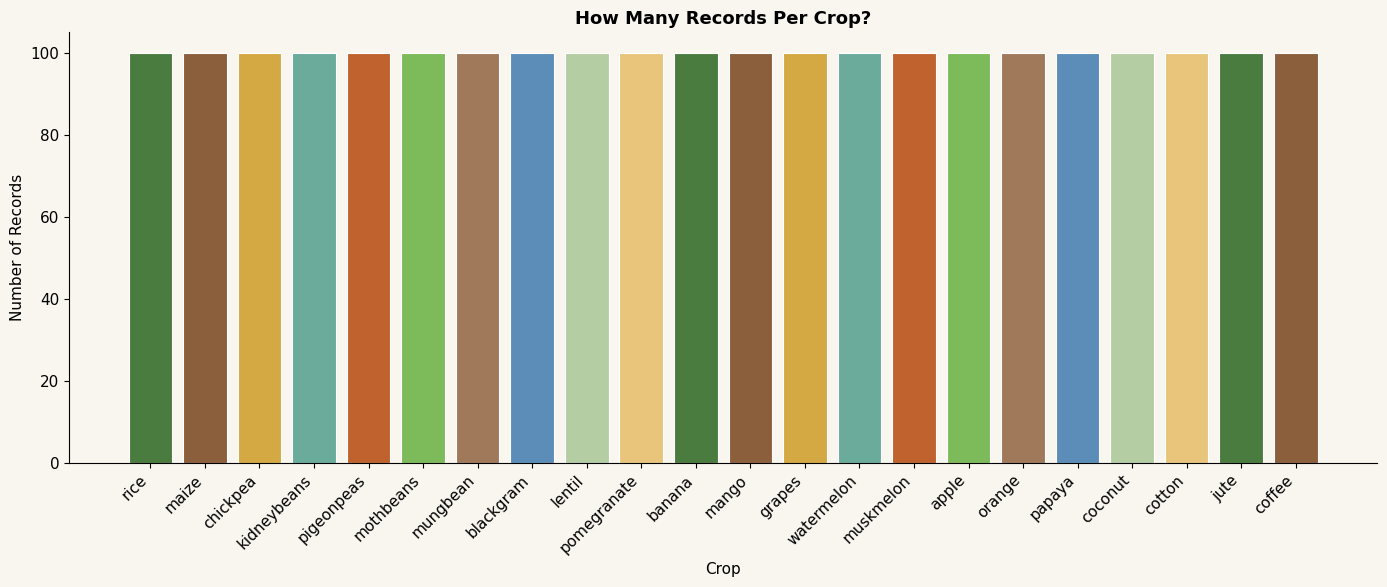

In [22]:
# how many records per crop
crop_counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(crop_counts.index, crop_counts.values,
              color=FARM_COLORS * 3,  # repeat colors for all 22 crops
              edgecolor='white', linewidth=0.8)

ax.set_title('How Many Records Per Crop?')
ax.set_xlabel('Crop')
ax.set_ylabel('Number of Records')
ax.set_facecolor('#f9f6f0')  # light earthy background
fig.patch.set_facecolor('#f9f6f0')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crop_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. NPK Nutrients — What Does Each Crop Need?

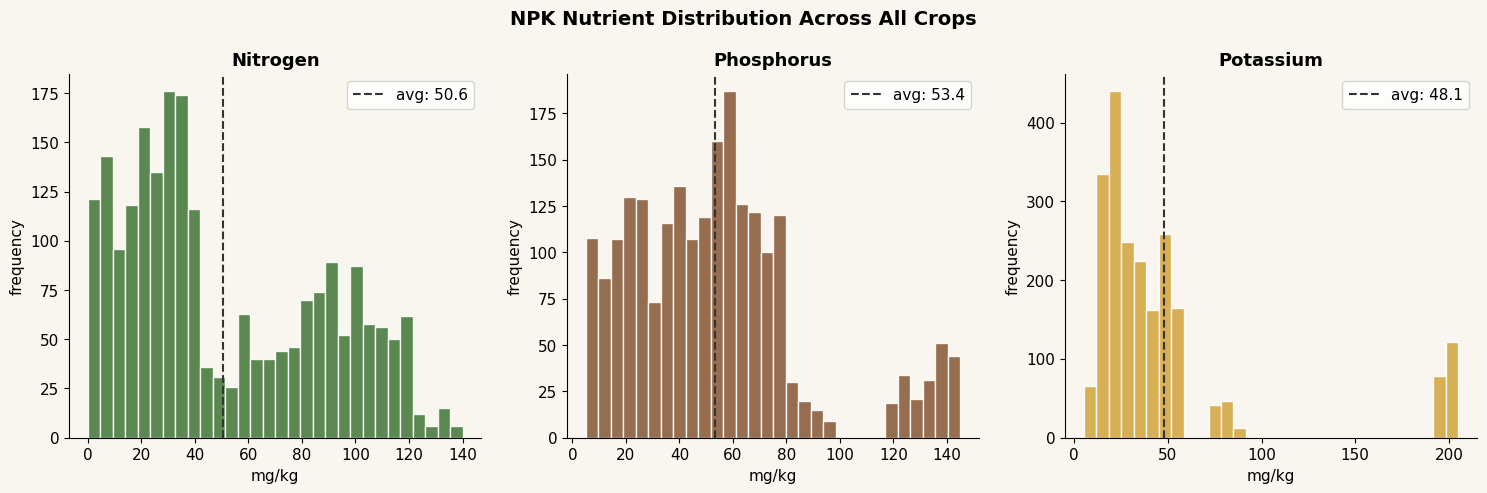

In [23]:
# nitrogen, phosphorus, potassium distributions
# these three nutrients are the main thing farmers check before planting

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#f9f6f0')

nutrient_info = [
    ('N', 'Nitrogen', '#4a7c3f'),
    ('P', 'Phosphorus', '#8b5e3c'),
    ('K', 'Potassium', '#d4a843'),
]

for ax, (col, name, color) in zip(axes, nutrient_info):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.9)
    ax.axvline(df[col].mean(), color='#333', linestyle='--',
               linewidth=1.5, label=f'avg: {df[col].mean():.1f}')
    ax.set_title(name)
    ax.set_xlabel('mg/kg')
    ax.set_ylabel('frequency')
    ax.set_facecolor('#f9f6f0')
    ax.legend()

plt.suptitle('NPK Nutrient Distribution Across All Crops', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('npk_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

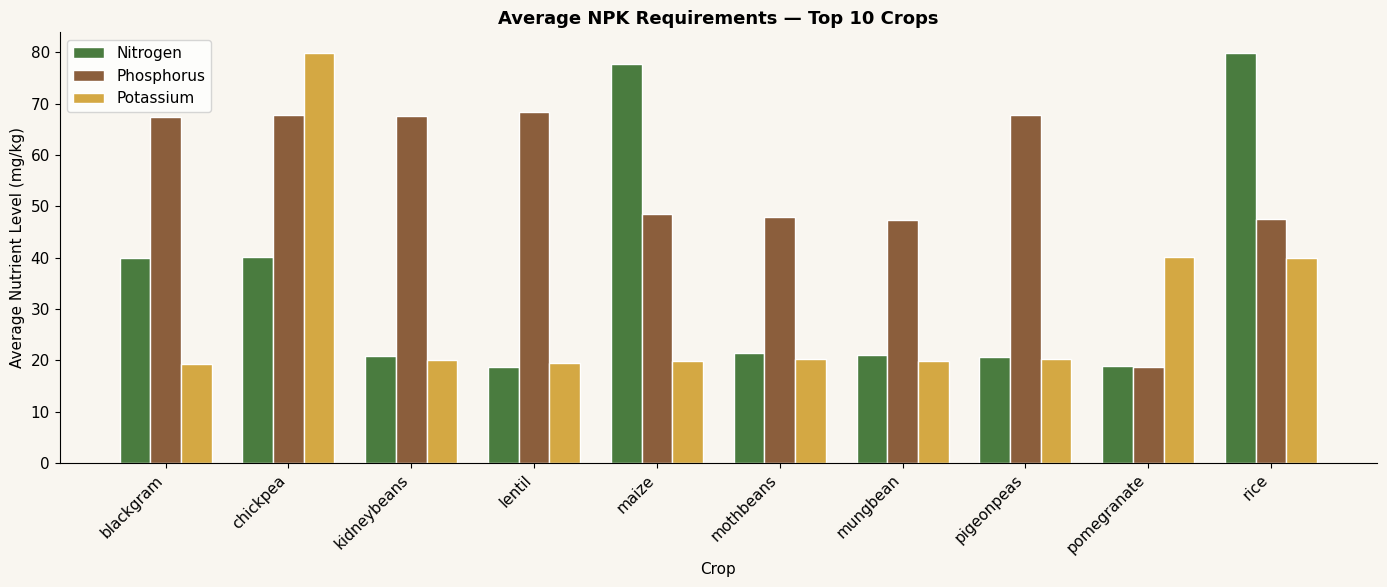

In [24]:
# average NPK for each crop — picking top 10 so the chart doesn't get too crowded
top10 = df['label'].value_counts().head(10).index
npk_avg = df[df['label'].isin(top10)].groupby('label')[['N', 'P', 'K']].mean()

x = np.arange(len(npk_avg))
w = 0.25  # bar width

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f9f6f0')
ax.set_facecolor('#f9f6f0')

ax.bar(x - w, npk_avg['N'], w, label='Nitrogen',   color='#4a7c3f', edgecolor='white')
ax.bar(x,     npk_avg['P'], w, label='Phosphorus', color='#8b5e3c', edgecolor='white')
ax.bar(x + w, npk_avg['K'], w, label='Potassium',  color='#d4a843', edgecolor='white')

ax.set_title('Average NPK Requirements — Top 10 Crops')
ax.set_xlabel('Crop')
ax.set_ylabel('Average Nutrient Level (mg/kg)')
ax.set_xticks(x)
ax.set_xticklabels(npk_avg.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('npk_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Rainfall — How Much Water Does Each Crop Need?

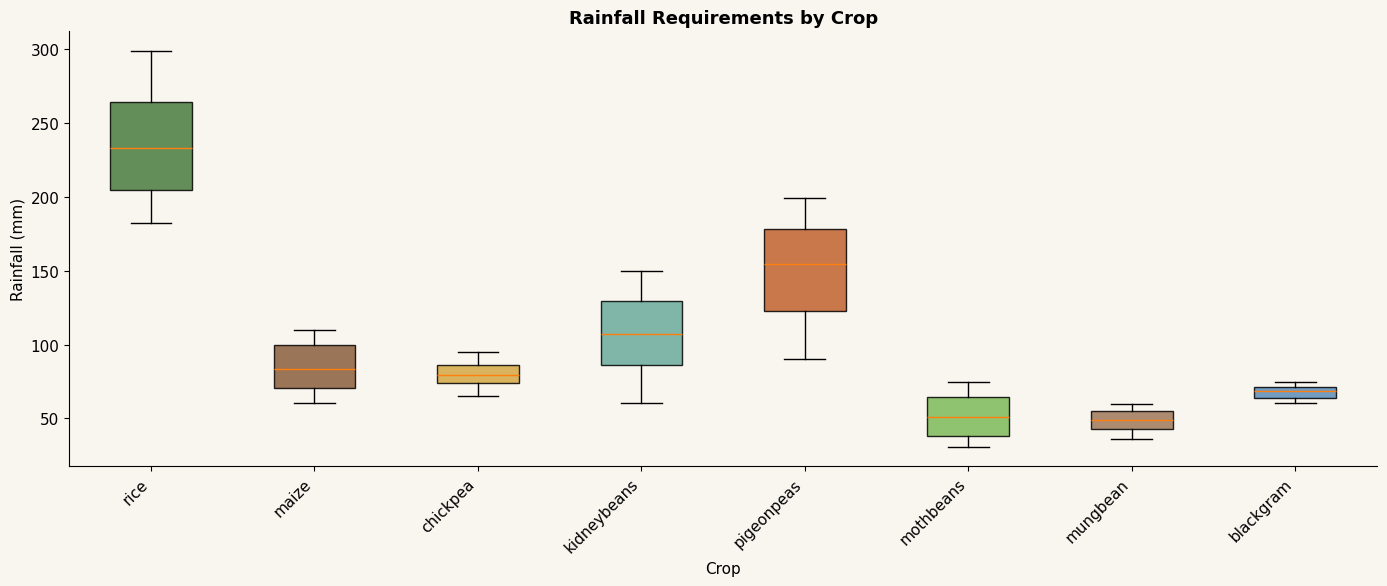

In [25]:
# box plot — good for showing the range and spread, not just averages
top8 = df['label'].value_counts().head(8).index.tolist()
df_top8 = df[df['label'].isin(top8)]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f9f6f0')
ax.set_facecolor('#f9f6f0')

data_groups = [df_top8[df_top8['label'] == c]['rainfall'].values for c in top8]
bp = ax.boxplot(data_groups, patch_artist=True, labels=top8)

# color each box with farming theme
for patch, color in zip(bp['boxes'], FARM_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title('Rainfall Requirements by Crop')
ax.set_xlabel('Crop')
ax.set_ylabel('Rainfall (mm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rainfall_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Statistical Analysis with SciPy

This is the part where we check if the patterns we're seeing are real or just coincidence.

In [26]:
# --- pearson correlation ---
# checking if higher nitrogen means more/less rainfall needed
print('=== Pearson Correlation: Nutrients vs Rainfall ===')
for nutrient in ['N', 'P', 'K']:
    r, p = pearsonr(df[nutrient], df['rainfall'])
    verdict = 'significant ✓' if p < 0.05 else 'not significant ✗'
    print(f'  {nutrient} vs rainfall:  r = {r:.3f},  p = {p:.4f}  →  {verdict}')

print()

# --- spearman correlation ---
# using spearman here because temperature and pH aren't perfectly linear
print('=== Spearman Correlation: Temperature vs pH ===')
rho, p = spearmanr(df['temperature'], df['ph'])
print(f'  rho = {rho:.3f},  p = {p:.4f}')

print()

# --- kruskal-wallis test ---
# does rainfall actually differ across crops or do they all need about the same?
print('=== Kruskal-Wallis Test: Does Rainfall Differ Across Crops? ===')
rain_groups = [df[df['label'] == c]['rainfall'].values for c in df['label'].unique()]
h, p = kruskal(*rain_groups)
print(f'  H = {h:.3f},  p = {p:.6f}')
if p < 0.05:
    print('  → yes, rainfall needs are significantly different across crops')
else:
    print('  → no significant difference found')

print()

# --- one-way anova ---
# same question but for nitrogen — do different crops need different nitrogen levels?
print('=== One-Way ANOVA: Nitrogen Levels Across Crops ===')
n_groups = [df[df['label'] == c]['N'].values for c in df['label'].unique()]
f, p = f_oneway(*n_groups)
print(f'  F = {f:.3f},  p = {p:.6f}')
if p < 0.05:
    print('  → nitrogen requirements are significantly different across crops')
else:
    print('  → no significant difference found')

=== Pearson Correlation: Nutrients vs Rainfall ===
  N vs rainfall:  r = 0.059,  p = 0.0056  →  significant ✓
  P vs rainfall:  r = -0.064,  p = 0.0027  →  significant ✓
  K vs rainfall:  r = -0.053,  p = 0.0121  →  significant ✓

=== Spearman Correlation: Temperature vs pH ===
  rho = 0.028,  p = 0.1932

=== Kruskal-Wallis Test: Does Rainfall Differ Across Crops? ===
  H = 1944.976,  p = 0.000000
  → yes, rainfall needs are significantly different across crops

=== One-Way ANOVA: Nitrogen Levels Across Crops ===
  F = 897.568,  p = 0.000000
  → nitrogen requirements are significantly different across crops


## 6. Correlation Heatmap

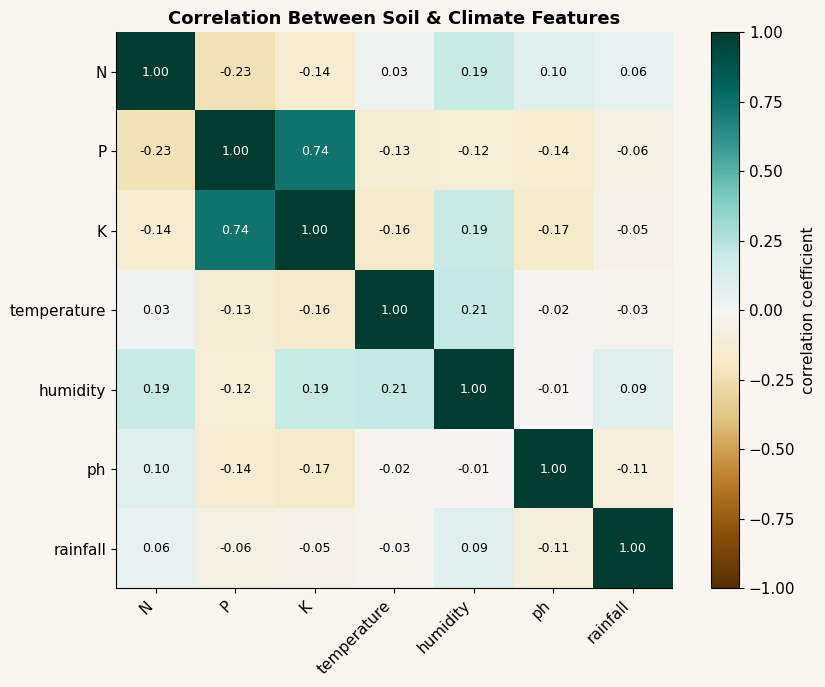

In [27]:
# heatmap showing how all the features relate to each other
# useful for spotting which factors actually move together

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#f9f6f0')
ax.set_facecolor('#f9f6f0')

# using a green-brown colormap to stay on theme
im = ax.imshow(corr, cmap='BrBG', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='correlation coefficient')

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_yticklabels(features)

# add the numbers inside each cell
for i in range(len(features)):
    for j in range(len(features)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Correlation Between Soil & Climate Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Temperature vs Humidity by Crop Group

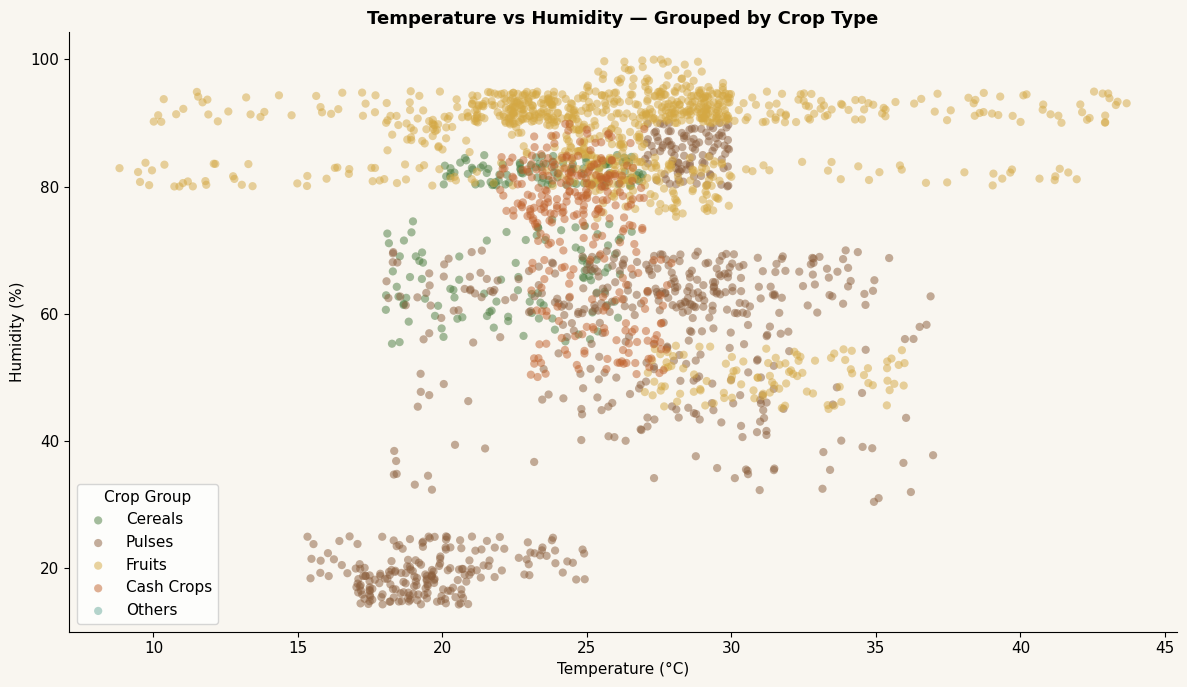

In [28]:
# grouping crops into categories to make the scatter less messy
crop_groups = {
    'Cereals':    ['rice', 'maize', 'wheat', 'barley'],
    'Pulses':     ['chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans',
                   'mungbean', 'blackgram', 'lentil'],
    'Fruits':     ['mango', 'banana', 'apple', 'grapes', 'watermelon',
                   'muskmelon', 'papaya', 'orange', 'coconut', 'pomegranate'],
    'Cash Crops': ['cotton', 'jute', 'coffee'],
}

def get_group(crop):
    for group, crops in crop_groups.items():
        if crop in crops:
            return group
    return 'Others'

df['crop_group'] = df['label'].apply(get_group)

group_colors = {
    'Cereals':    '#4a7c3f',
    'Pulses':     '#8b5e3c',
    'Fruits':     '#d4a843',
    'Cash Crops': '#c0622d',
    'Others':     '#6aab9c',
}

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f6f0')
ax.set_facecolor('#f9f6f0')

for group, color in group_colors.items():
    subset = df[df['crop_group'] == group]
    ax.scatter(subset['temperature'], subset['humidity'],
               c=color, label=group, alpha=0.5, s=35, edgecolors='none')

ax.set_title('Temperature vs Humidity — Grouped by Crop Type')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.legend(title='Crop Group', framealpha=0.8)
plt.tight_layout()
plt.savefig('temp_humidity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Soil pH by Crop Group

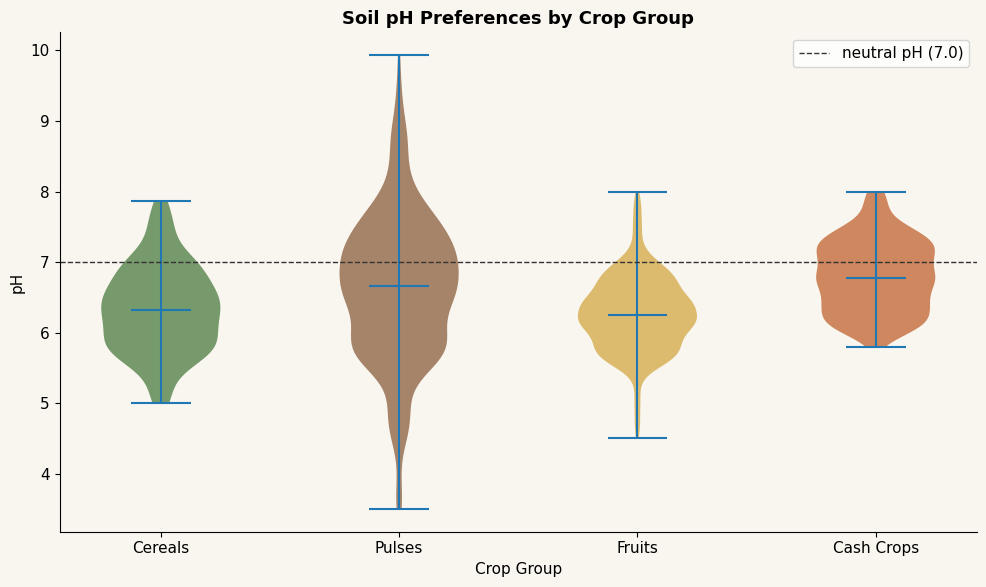

In [29]:
# only include groups that actually have data
groups_list = [g for g in group_colors.keys() if len(df[df['crop_group'] == g]) > 0]
ph_data = [df[df['crop_group'] == g]['ph'].values for g in groups_list]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f9f6f0')
ax.set_facecolor('#f9f6f0')

vp = ax.violinplot(ph_data, positions=range(len(groups_list)), showmedians=True)

for body, color in zip(vp['bodies'], [group_colors[g] for g in groups_list]):
    body.set_facecolor(color)
    body.set_alpha(0.75)

ax.axhline(y=7.0, color='#333', linestyle='--', linewidth=1, label='neutral pH (7.0)')
ax.set_xticks(range(len(groups_list)))
ax.set_xticklabels(groups_list)
ax.set_title('Soil pH Preferences by Crop Group')
ax.set_xlabel('Crop Group')
ax.set_ylabel('pH')
ax.legend()
plt.tight_layout()
plt.savefig('ph_violin.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Key Findings

In [30]:
# wrapping up — what did we actually find?

high_rain_crop = df.groupby('label')['rainfall'].mean().idxmax()
low_rain_crop  = df.groupby('label')['rainfall'].mean().idxmin()
high_n_crop    = df.groupby('label')['N'].mean().idxmax()
low_ph_crop    = df.groupby('label')['ph'].mean().idxmin()

r_n_rain, _ = pearsonr(df['N'], df['rainfall'])
r_k_rain, _ = pearsonr(df['K'], df['rainfall'])

print('=' * 50)
print('        KEY FINDINGS')
print('=' * 50)
print(f'\n dataset: {len(df)} records, {df["label"].nunique()} crops')
print(f'\n crops needing most rainfall : {high_rain_crop}')
print(f' crops needing least rainfall: {low_rain_crop}')
print(f' highest avg nitrogen demand : {high_n_crop}')
print(f' most acidic soil preference : {low_ph_crop}')
print(f'\n nitrogen-rainfall correlation : r = {r_n_rain:.3f}')
print(f' potassium-rainfall correlation: r = {r_k_rain:.3f}')
print()
print(' rainfall differs significantly across crops (Kruskal-Wallis p < 0.05)')
print(' nitrogen levels differ significantly across crops (ANOVA p < 0.05)')
print('=' * 50)

        KEY FINDINGS

 dataset: 2200 records, 22 crops

 crops needing most rainfall : rice
 crops needing least rainfall: muskmelon
 highest avg nitrogen demand : cotton
 most acidic soil preference : kidneybeans

 nitrogen-rainfall correlation : r = 0.059
 potassium-rainfall correlation: r = -0.053

 rainfall differs significantly across crops (Kruskal-Wallis p < 0.05)
 nitrogen levels differ significantly across crops (ANOVA p < 0.05)


---

## Notes

This analysis is part of a bigger project I've been working on — [AgroSense](https://github.com/Nikhitha1710/AgroSense), a full stack agricultural advisory system that gives farmers real-time crop recommendations based on soil sensor data. This notebook explores the statistical side of that same data to understand *why* certain soil conditions suit certain crops.

Dataset: [Kaggle — Indian Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)